Размер датасета: (1059, 11)

Колонки: ['floor', 'total_area', 'living_area', 'kitchen_area', 'year', 'flat_status', 'flat_type', 'metro', 'metro_minutes', 'description', 'price']

Первые 5 строк:
   floor  total_area  living_area  kitchen_area  year  flat_status flat_type  \
0      4      125.50         75.8          22.9  1876            1    4-комн   
1      3       41.50         26.4           6.0  1964            1    2-комн   
2      3       80.39         44.9          10.2  2025            0    3-комн   
3      4       65.10         27.0          19.0  1983            1    2-комн   
4     10       38.50         16.6          10.5  2015            1    1-комн   

                                            metro  metro_minutes  \
0          Балтийская, Василеостровская, Нарвская              5   
1              Московская, Бухарестская, Звездная              6   
2        Василеостровская, Спортивная, Чкаловская              5   
3  Улица Дыбенко, Проспект Большевиков, Ладожская  

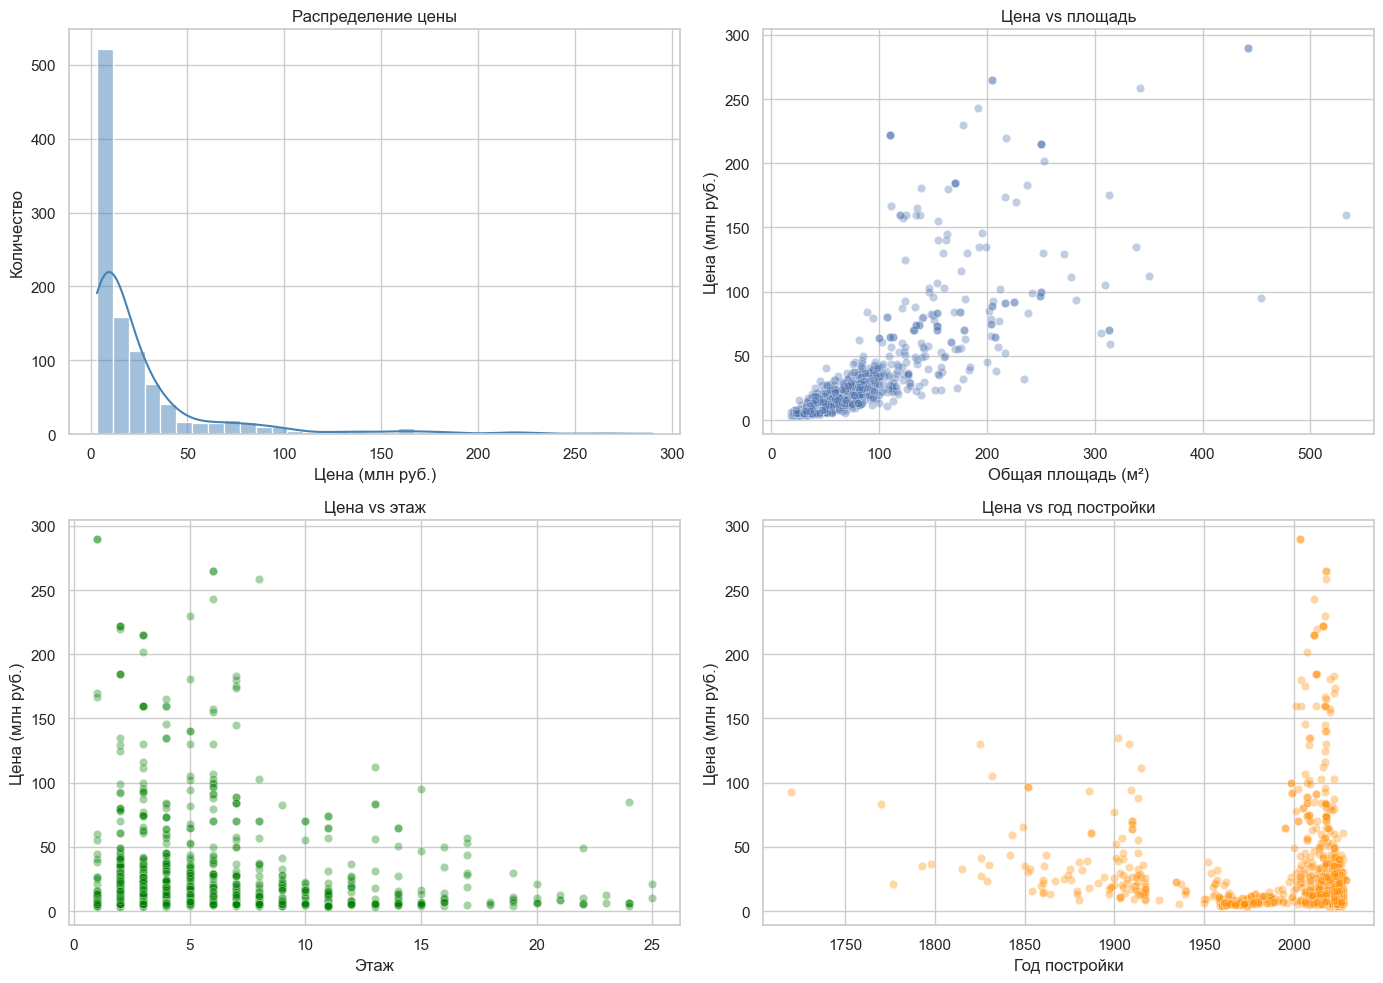

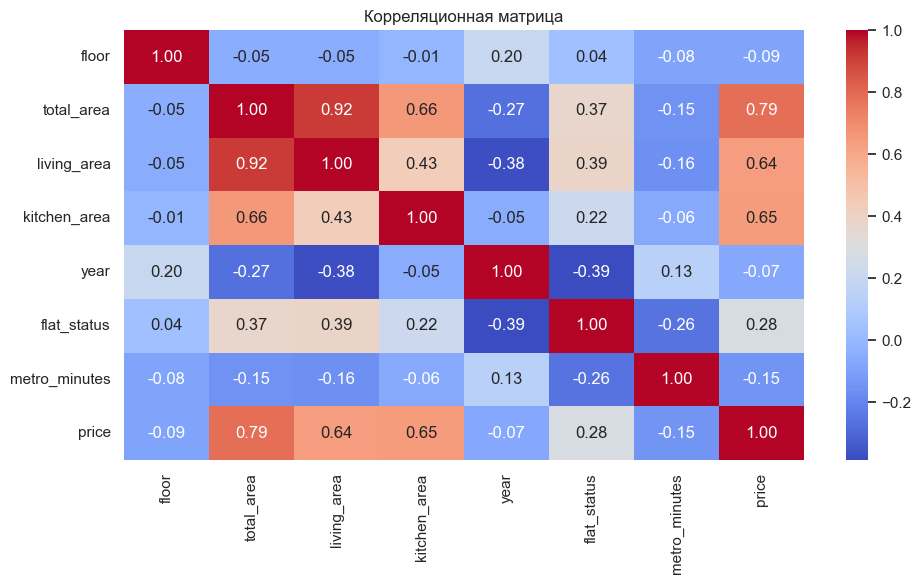


Linear Regression (Только числа)
  R²: 0.6750
  MAE: 10,940,441 руб.
  MAPE: 65.68%


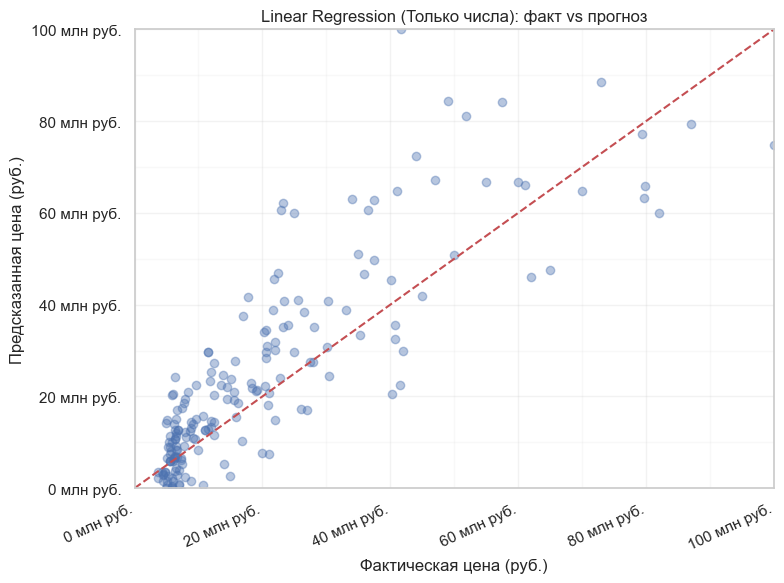


Linear Regression (Числа + Текст)
  R²: 0.6439
  MAE: 12,515,306 руб.
  MAPE: 73.69%


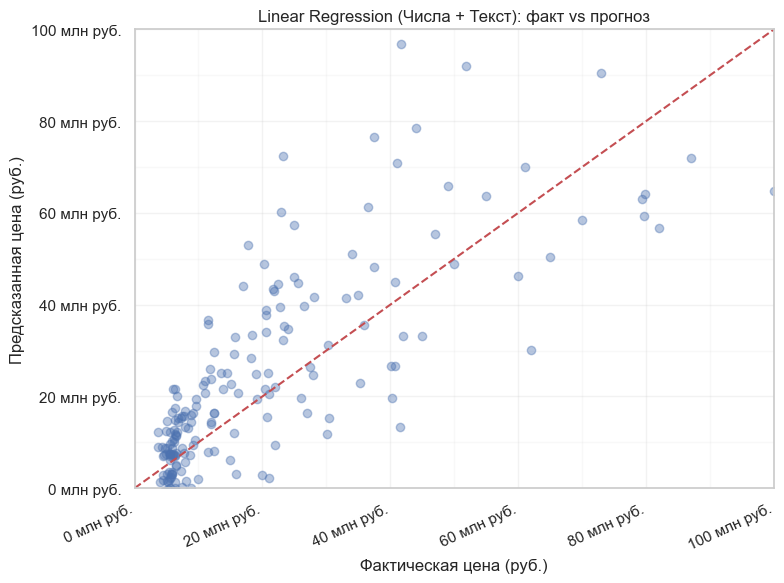


KNN (Только числа)
  R²: 0.6393
  MAE: 9,045,130 руб.
  MAPE: 30.38%


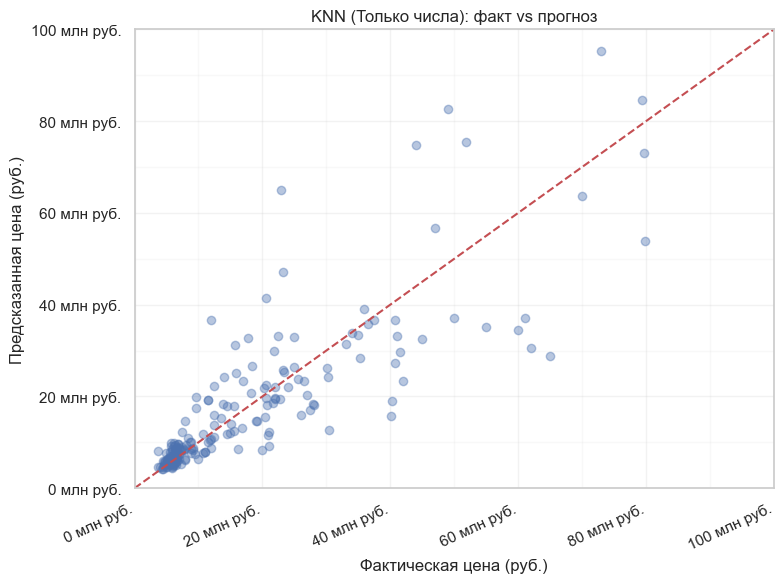


KNN (Числа + Текст)
  R²: 0.6137
  MAE: 9,284,940 руб.
  MAPE: 32.04%


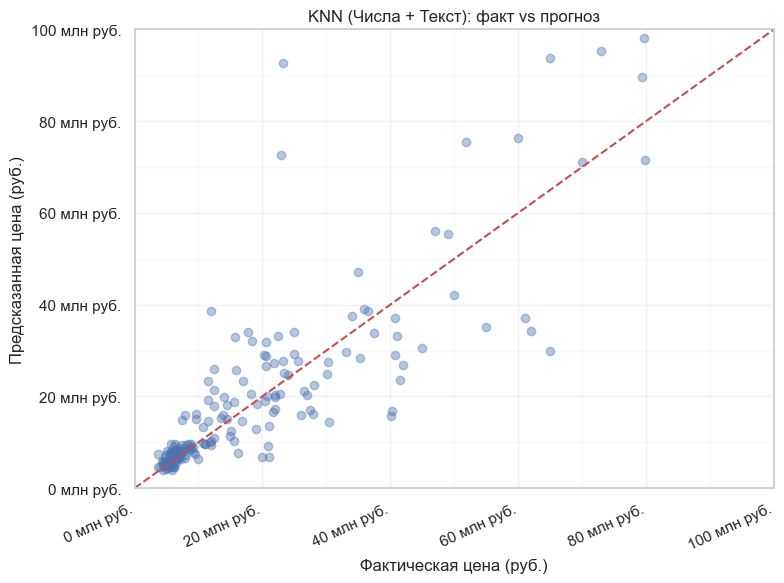


Random Forest (Только числа)
  R²: 0.7187
  MAE: 7,911,735 руб.
  MAPE: 27.03%


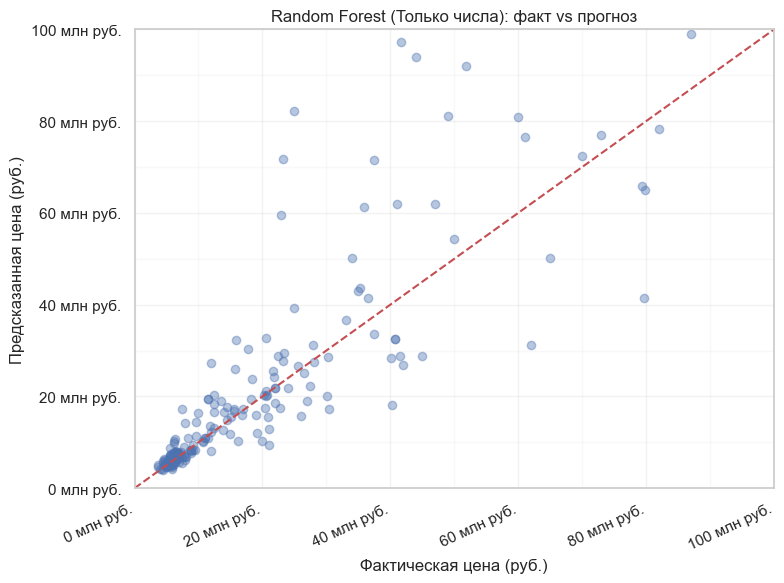


Random Forest (Числа + Текст)
  R²: 0.6700
  MAE: 8,879,135 руб.
  MAPE: 30.69%


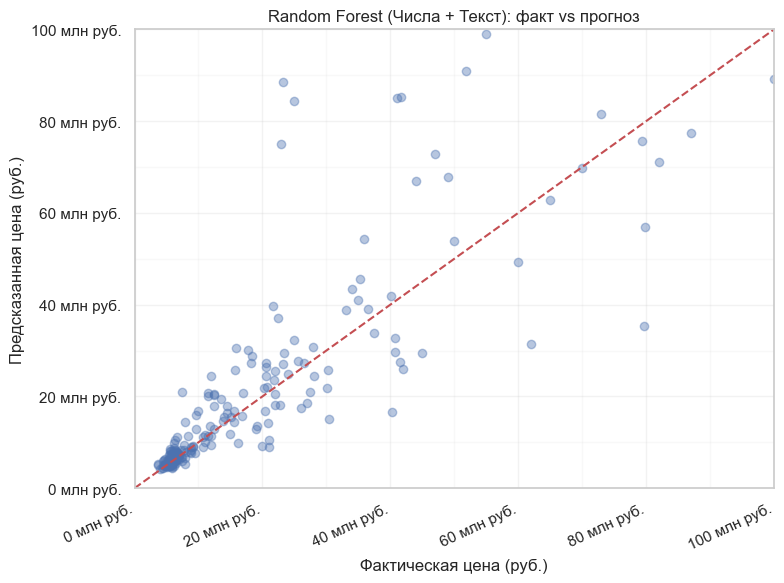


Сводная таблица моделей:
                                         R2           MAE      MAPE
Linear Regression (Только числа)   0.675027  1.094044e+07  0.656762
Linear Regression (Числа + Текст)  0.643931  1.251531e+07  0.736866
KNN (Только числа)                 0.639318  9.045130e+06  0.303805
KNN (Числа + Текст)                0.613702  9.284940e+06  0.320380
Random Forest (Только числа)       0.718742  7.911735e+06  0.270347
Random Forest (Числа + Текст)      0.670028  8.879135e+06  0.306949


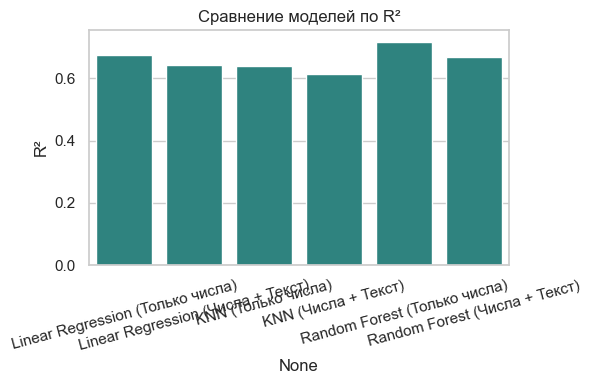

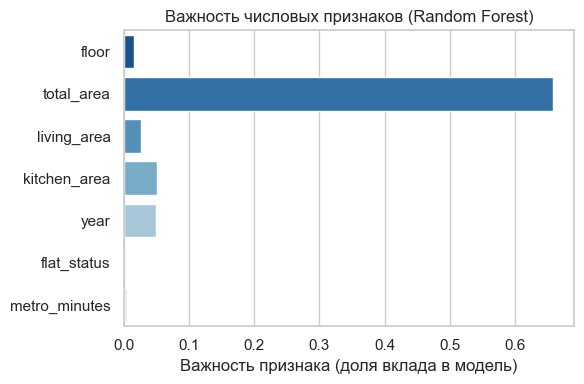

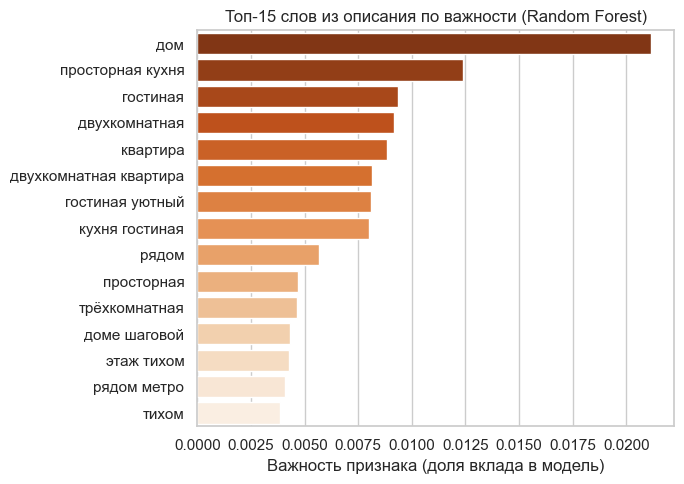


Пример прогноза (Random Forest): 189,169,270 руб.


In [2]:
# КУРСОВОЙ ПРОЕКТ
# Анализ и прогноз цен на недвижимость

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter, MultipleLocator
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
import joblib
from scipy.sparse import hstack

# Единый стиль графиков
sns.set(style="whitegrid")

# 1. ЗАГРУЗКА ДАННЫХ
df = pd.read_csv("data/saint_petersburg_housing_data.csv")

print("Размер датасета:", df.shape)
print("\nКолонки:", df.columns.tolist())
print("\nПервые 5 строк:")
print(df.head())

# 2. ПЕРВИЧНЫЙ АНАЛИЗ
numeric_cols = ["floor", "total_area", "living_area", "kitchen_area", "year", "flat_status", "metro_minutes", "price"]
print("\nОписание числовых признаков:")
print(df[numeric_cols].describe())

# 3. ВИЗУАЛИЗАЦИЯ ОСНОВНЫХ ЗАВИСИМОСТЕЙ
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(df["price"] / 1_000_000, kde=True, bins=35, color="steelblue")
plt.title("Распределение цены")
plt.xlabel("Цена (млн руб.)")
plt.ylabel("Количество")

plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x="total_area", y=df["price"] / 1_000_000, alpha=0.35)
plt.title("Цена vs площадь")
plt.xlabel("Общая площадь (м²)")
plt.ylabel("Цена (млн руб.)")

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x="floor", y=df["price"] / 1_000_000, alpha=0.35, color="green")
plt.title("Цена vs этаж")
plt.xlabel("Этаж")
plt.ylabel("Цена (млн руб.)")

plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x="year", y=df["price"] / 1_000_000, alpha=0.35, color="darkorange")
plt.title("Цена vs год постройки")
plt.xlabel("Год постройки")
plt.ylabel("Цена (млн руб.)")

plt.tight_layout()
plt.show()

# 4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
plt.figure(figsize=(10, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

# 5. ПОДГОТОВКА ПРИЗНАКОВ
num_features = ["floor", "total_area", "living_area", "kitchen_area", "year", "flat_status", "metro_minutes"]
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df[num_features].values)
y = df["price"].values

stop_words_ru = ["и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то", "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за", "бы", "по", "только", "ее", "мне", "было", "вот", "от", "меня", "еще", "нет", "о", "из", "ему", "теперь", "когда", "даже", "ну", "вдруг", "ли", "если", "уже", "или", "ни", "быть", "был", "него", "до", "вас", "нибудь", "опять", "уж", "вам", "ведь", "там", "потом", "себя", "ничего", "ей", "может", "они", "тут", "где", "есть", "надо", "ней", "для", "мы", "тебя", "их", "чем", "была", "сам", "чтоб", "без", "будто", "чего", "раз", "тоже", "себе", "под", "будет", "ж", "тогда", "кто", "этот", "того", "потому", "этого", "какой", "совсем", "ним", "здесь", "этом", "один", "почти", "мой", "тем", "чтобы", "нее", "сейчас", "были", "куда", "зачем", "всех", "никогда", "можно", "при", "наконец", "два", "об", "другой", "хоть", "после", "над", "больше", "тот", "через", "эти", "нас", "про", "всего", "них", "какая", "много", "разве", "три", "эту", "моя", "впрочем", "хорошо", "свою", "этой", "перед", "иногда", "лучше", "чуть", "том", "нельзя", "такой", "им", "более", "всегда", "конечно", "всю", "между"]
tfidf = TfidfVectorizer(max_features=100, stop_words=stop_words_ru, ngram_range=(1, 2))
X_text = tfidf.fit_transform(df["description"])
X = hstack([X_num_scaled, X_text])

X_num_train, X_num_test, y_train, y_test = train_test_split(X_num_scaled, y, test_size=0.2, random_state=42)
X_combined_train, X_combined_test, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

datasets = {
    "Только числа": (X_num_train, X_num_test),
    "Числа + Текст": (X_combined_train, X_combined_test)
}

# 6. ОБУЧЕНИЕ МОДЕЛЕЙ
base_models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
}

results = {}
mln_rub_formatter = FuncFormatter(lambda x, pos: f"{x:.0f} млн руб.")

for name, base_model in base_models.items():
    for data_name, (X_train, X_test) in datasets.items():
        model_name = f"{name} ({data_name})"
        model = clone(base_model)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        results[model_name] = {"model": model, "r2": r2, "mae": mae, "mape": mape, "y_pred": y_pred}

        print(f"\n{model_name}")
        print(f"  R²: {r2:.4f}")
        print(f"  MAE: {mae:,.0f} руб.")
        print(f"  MAPE: {mape:.2%}")

        # Факт vs прогноз в млн руб.
        y_test_mln = y_test / 1_000_000
        y_pred_mln = y_pred / 1_000_000

        plt.figure(figsize=(8, 6))
        plt.scatter(y_test_mln, y_pred_mln, alpha=0.4)
        plt.plot([0, 100], [0, 100], "r--")
        plt.title(f"{model_name}: факт vs прогноз")
        plt.xlabel("Фактическая цена (руб.)")
        plt.ylabel("Предсказанная цена (руб.)")
        plt.xlim(0, 100)
        plt.ylim(0, 100)

        ax = plt.gca()
        ax.xaxis.set_major_formatter(mln_rub_formatter)
        ax.yaxis.set_major_formatter(mln_rub_formatter)
        ax.xaxis.set_major_locator(MultipleLocator(20))
        ax.yaxis.set_major_locator(MultipleLocator(20))
        ax.xaxis.set_minor_locator(MultipleLocator(10))
        ax.yaxis.set_minor_locator(MultipleLocator(10))
        plt.xticks(rotation=25, ha="right")
        plt.grid(which="major", alpha=0.25)
        plt.grid(which="minor", alpha=0.12)

        plt.tight_layout()
        plt.show()

# 7. СРАВНЕНИЕ МОДЕЛЕЙ
metrics_df = pd.DataFrame(
    {name: {"R2": v["r2"], "MAE": v["mae"], "MAPE": v["mape"]} for name, v in results.items()}
).T

print("\nСводная таблица моделей:")
print(metrics_df)

plt.figure(figsize=(6, 4))
sns.barplot(x=metrics_df.index, y=metrics_df["R2"], color=sns.color_palette("viridis", 3)[1])
plt.ylabel("R²")
plt.title("Сравнение моделей по R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 8. ВАЖНОСТЬ ПРИЗНАКОВ RANDOM FOREST
rf_model = results["Random Forest (Числа + Текст)"]["model"]
num_importances = rf_model.feature_importances_[: len(num_features)]

plt.figure(figsize=(6, 4))
sns.barplot(x=num_importances, y=num_features, hue=num_features, palette="Blues_r", legend=False)
plt.title("Важность числовых признаков (Random Forest)")
plt.xlabel("Важность признака (доля вклада в модель)")
plt.tight_layout()
plt.show()

text_importances = rf_model.feature_importances_[len(num_features) :]
words = tfidf.get_feature_names_out()

top_n = 15
top_idx = text_importances.argsort()[-top_n:][::-1]
top_words = [words[i] for i in top_idx]
top_vals = [text_importances[i] for i in top_idx]

plt.figure(figsize=(7, 5))
sns.barplot(x=top_vals, y=top_words, hue=top_words, palette="Oranges_r", legend=False)
plt.title("Топ-15 слов из описания по важности (Random Forest)")
plt.xlabel("Важность признака (доля вклада в модель)")
plt.tight_layout()
plt.show()

# 9. ПРИМЕР ПРЕДСКАЗАНИЯ
example_num = [[5, 65.0, 40.0, 12.0, 2015, 1, 7]]
example_text = tfidf.transform(["евроремонт, просторная кухня, рядом с метро, дом сдан"])
example_X = hstack([example_num, example_text])
example_pred = rf_model.predict(example_X)[0]

print(f"\nПример прогноза (Random Forest): {example_pred:,.0f} руб.")